In [118]:
import numpy as np
import numpy.linalg as la
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import DictionaryLearning
import itertools

In [119]:
npzload = np.load("word_data.npz")
WORDVECS = npzload['vectors']
WORDPS = npzload['probs']
IDX2VOCAB = npzload['words']
VOCAB2IDX = {tok: i for i, tok in enumerate(IDX2VOCAB)}

In [120]:
M = WORDVECS - np.dot(WORDPS, WORDVECS)
N = la.norm(M, axis = 1)
_, evecs = la.eigh(np.dot(M.T, M))
biasvec = evecs[:,299]

def top(vec, n) :
    scores = np.dot(M, vec)
    top_unsorted = np.argpartition(scores, -n)[-n:]
    top = top_unsorted[np.argsort(scores[top_unsorted])][::-1]
    return top

def topcos(vec, n) :
    scores = np.dot(M, vec)/N
    top_unsorted = np.argpartition(scores, -n)[-n:]
    top = top_unsorted[np.argsort(scores[top_unsorted])][::-1]
    return top

def dominant(vec, exclude, depth, alpha,) :
    G = np.copy(M[topcos(vec, depth)])
    for v in exclude :
        G = G - np.outer(G.dot(v), v)
    dict1 = DictionaryLearning(n_components=1, alpha=alpha)
    dict1.fit(G)
    f = dict1.components_[0]
    return f/la.norm(f)

def dominant2(vec, exclude, depth, ) :
    G = np.copy(M[topcos(vec, depth)])
    for v in exclude :
        G = G - np.outer(G.dot(v), v)
    f = np.sum(G, axis=0)
    return f/la.norm(f)

def decompose(vec, n, depth, alpha) :
    stub = np.copy(vec) - np.dot(vec, biasvec)*biasvec
    subvecs = [biasvec]
    for _ in range(n) :
        subvec = dominant(vec=stub, exclude=subvecs, depth=depth, alpha=alpha)
        subvecs.append(subvec)
        stub = stub - np.dot(subvec, stub) * subvec
    return np.array(subvecs), stub

def decompose2(vec, n, depth) :
    stub = np.copy(vec) - np.dot(vec, biasvec)*biasvec
    subvecs = [biasvec]
    for _ in range(n) :
        subvec = dominant2(vec=stub, exclude=subvecs, depth=depth)
        subvecs.append(subvec)
        stub = stub - np.dot(subvec, stub) * subvec
    return np.array(subvecs), stub

In [121]:
def all_groups_4(n=16):
    """List of tuples of 4 indices from 0..n-1."""
    return list(itertools.combinations(range(n), 4))

def precompute_group_scores(logpwt, logpt, c1=1):
    """
    pwt16: (T,16)
    Returns:
      groups: list of 4-tuples
      group_score: (num_groups,) where group_score[g] = max_t logP(G,t)
      logP_tg: (T, num_groups) if you want it (optional)
    """
    groups = all_groups_4(16)
    idx = np.array(groups, dtype=np.int64)
    logpgtn = logpwt[:, idx].sum(axis=2)
    #max_logpgtn = logpgtn.max(axis=1, keepdims=True)
    max_logpgtn = np.log(np.exp(logpgtn).sum(axis=1, keepdims=True))
    logP_tg = logpgtn - c1*max_logpgtn + logpt
    #logP_g = logP_tg.max(axis=0)
    logP_g = np.log(np.exp(logP_tg).sum(axis=0))
    topic = np.argmax(logP_tg, axis=0)
    return groups, logP_g, logP_tg, topic

def solve_best_partition(groups, group_score):
    """
    groups: list of 4-tuples length 1820
    group_score: (1820,)
    Returns: (best_score, chosen_group_indices)
    """
    # Precompute group masks
    group_masks = np.zeros(len(groups), dtype=np.int32)
    for gi, g in enumerate(groups):
        m = 0
        for i in g:
            m |= (1 << i)
        group_masks[gi] = m

    # For speed: for each word i, list candidate group indices that include i
    contains = [[] for _ in range(16)]
    for gi, m in enumerate(group_masks):
        for i in range(16):
            if m & (1 << i):
                contains[i].append(gi)

    FULL = (1 << 16) - 1
    NEG = -1e100

    dp = np.full(1 << 16, NEG, dtype=np.float64)
    parent = np.full(1 << 16, -1, dtype=np.int32)      # store chosen group index
    parent_prev = np.full(1 << 16, -1, dtype=np.int32) # store previous mask

    dp[0] = 0.0

    for mask in range(1 << 16):
        # only consider masks with word-count multiple of 4 (0,4,8,12,16)
        k = bin(mask).count("1")
        if dp[mask] <= NEG/2: 
            continue
        if k % 4 != 0:
            continue
        if mask == FULL:
            continue

        # find smallest unused word
        unused = (~mask) & FULL
        i = (unused & -unused).bit_length() - 1  # index of least significant set bit

        # try all groups that contain i and don't overlap with mask
        for gi in contains[i]:
            gm = group_masks[gi]
            if gm & mask:
                continue
            newmask = mask | gm
            val = dp[mask] + group_score[gi]
            if val > dp[newmask]:
                dp[newmask] = val
                parent[newmask] = gi
                parent_prev[newmask] = mask

    best_score = dp[FULL]

    # reconstruct groups
    chosen = []
    cur = FULL
    while cur != 0 and parent[cur] != -1:
        gi = parent[cur]
        chosen.append(gi)
        cur = parent_prev[cur]
    chosen.reverse()

    return best_score, chosen



In [122]:
words16 = ['insurance', 'market', 'almanac', 'tan', 'number', 'college', 'position', 'team','exchange', 'contact', 'interaction', 'dealings', 'arrival', 'flight', 'gate','destination']
#words16 = ['silver', 'mint', 'study', 'time', 'fix', 'budding', 'mass', 'bundle', 'fresh', 'current', 'wad', 'sand', 'naive', 'fortune', 'length', 'new']
#problem w/ _ word type puzzles. copy+right, copy+cat, copy+pasta, copy+writer are all singular words, which GLoVe does not capture <- this issue is not easily solveable.
#problem w/ [x]word type puzzles. [frost]y, [mist]letoe, [rain]maker, [snow]man <- this issue is solveable

In [154]:
words16 = ['award','crown','cup','title','gloves','guard','robe','shorts','boat','crew','halter','scoop','cone','globe','leopard','pea']
words16 = ['garage','meter','street','valet','acre','bushel','foot','stone','bridge','frame','lens','temple','flood','lime','pilot','traffic']
words16 = ['author','cooper','title','feathers','synopsis','peck','bill','price','wreck','break','quote','wings','total','damage','webbing','grant']

In [155]:
wordM = np.copy(M[[VOCAB2IDX[w] for w in words16]])
wordFreqs = WORDPS[[VOCAB2IDX[w] for w in words16]]
topicspace = np.array([]).reshape(0,300)
for word in words16 :
    subvecs, _ = decompose(np.copy(M[VOCAB2IDX[word]]), 30, 13, 0.5)
    topicspace = np.vstack((topicspace, subvecs[1:]))
totalspace = topicspace

In [156]:
#Pt = np.mean(WORDPS[np.argsort(np.dot(topicspace, M.T), axis=1)[:, -20:]], axis=1)

In [157]:
Pt = np.array([1 for _ in range(len(totalspace))], dtype=float)
Pt = Pt[:, None]
logpwt = 0.5*np.dot(totalspace, wordM.T) + np.log(wordFreqs)

groups, group_score, logP_tg, group_topic = precompute_group_scores(logpwt, np.log(Pt), c1=1)

In [158]:
best_score, chosen_group_indices = solve_best_partition(groups, group_score)

solution_groups = [groups[gi] for gi in chosen_group_indices]
solution_words = [[words16[i] for i in g] for g in solution_groups]

known_groups = [[0,1,2,3], [4,5,6,7], [8,9,10,11], [12,13,14,15]]
print("Best score:", best_score, sum(group_score[[0, 1325, 1750, 1819]]))
loggroupnaive = np.sum(np.log(wordFreqs)[groups], axis=1)
for i, gw in enumerate(solution_words):
    print(gw, group_score[chosen_group_indices[i]])

Best score: -16.192688459239452 -17.010805955806042
['author', 'title', 'synopsis', 'quote'] -2.8969572276503968
['cooper', 'peck', 'bill', 'grant'] -3.804408264648332
['feathers', 'break', 'wings', 'webbing'] -7.710374279073378
['price', 'wreck', 'total', 'damage'] -1.780948687867346


In [159]:
for gi in [groups.index(tuple(sorted(g))) for g in known_groups] :
    print(group_topic[gi], IDX2VOCAB[top(totalspace[group_topic[gi]], 5)], group_score[gi])

92 ['sanam' 'durbar' "xi'an" 'royal' 'luang'] -1.9590347585400374
150 ['peck' 'scott' 'craig' 'gregory' 'carolyn'] -4.8164155380154545
240 ['sunken' 'wreckage' 'wreck' 'divers' 'sank'] -6.146052075340214
422 ['ternary' 'synthesis' 'morphological' 'binary' 'melanin'] -4.089303583910335


In [160]:
def partition_scores_all(score_by_group, n=16):
    """
    Enumerate ALL unlabeled partitions of {0..n-1} into 4 groups of 4.
    Returns np.ndarray of shape (2627625,) for n=16.
    """
    elems = tuple(range(n))
    scores = []

    def rec(remaining, acc):
        if not remaining:
            scores.append(acc)
            return
        first = remaining[0]
        rest = remaining[1:]
        # choose 3 others to form the next group, anchored by 'first' to avoid duplicates
        for combo in itertools.combinations(rest, 3):
            g = tuple(sorted((first,) + combo))
            s = score_by_group[g]
            rem2 = tuple(x for x in remaining if x not in g)
            rec(rem2, acc + s)

    rec(elems, 0.0)
    return np.array(scores, dtype=np.float32)
score_by_group = {g: float(group_score[i]) for i, g in enumerate(groups)}
allscores = partition_scores_all(score_by_group)

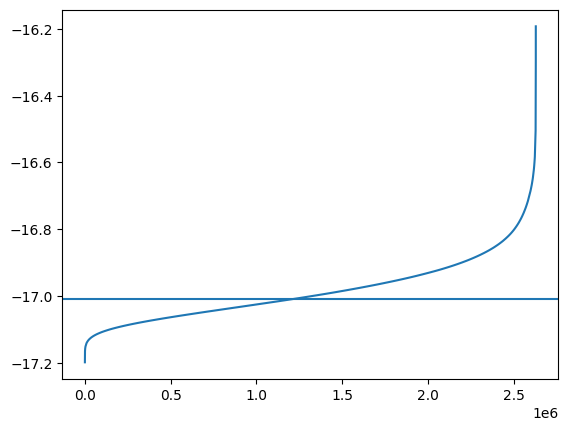

In [161]:
plt.plot(np.sort(allscores))
plt.axhline(y=sum(group_score[[0, 1325, 1750, 1819]]))